# 01 - CV Transformer Explainability


In [27]:
# Requires: pip install -e .

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import networkx as nx
from graph_utils import calc_p_ratio_box, draw_graph_comparison
from course_project.config import ExperimentConfig
from course_project.data import load_dataset, resolve_dataset_splits
from course_project.graph import build_graph
from course_project.models import create_model, resolve_model_inputs
from course_project.plotting import PAPER_COLORS, apply_editorial_style, paper_caption, style_axes


apply_editorial_style()




In [28]:
from course_project.runner import run_graph_cv_experiment

import random

force_train = True
seed = random.SystemRandom().randrange(1, 2**31)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
print('run seed:', seed)

time_lag_steps = 0
time_lag_weight = 0
shuffle_dataset_within_source = True
mix_holdout_across_sources = True
full_dataset_path = 'mixed'

aux_source_path = Path('../data/data_aux_opt_lowT_448sims_noang_bidirect.pt')
aux_filtered_path = aux_source_path.with_name('data_aux_opt_lowT_448sims_noang_bidirect_filtered.pt')
aux_filter_meta_path = aux_filtered_path.with_suffix('.json')
# aux_exclude_sim_indices = [44, 41, 0, 4, 3, 52, 20, 86, 31, 67, 75, 74, 80, 1, 30, 82, 91, 83, 77]
aux_exclude_sim_indices = [44, 41, 0, 4, 3, 52, 20, 86, 31, 67, 75, 74, 80, 1, 30, 82, 91, 83, 77]
existing_aux_meta = {}
if aux_filter_meta_path.exists():
    existing_aux_meta = json.loads(aux_filter_meta_path.read_text())
aux_sims = torch.load(aux_source_path, weights_only=False)
kept_original_indices = [int(i) for i in range(len(aux_sims)) if i not in set(aux_exclude_sim_indices)]
needs_aux_refresh = (
    force_train
    or (not aux_filtered_path.exists())
    or existing_aux_meta.get('excluded_sim_idx') != aux_exclude_sim_indices
    or existing_aux_meta.get('kept_original_indices') != kept_original_indices
)
if needs_aux_refresh:
    aux_keep = [sim for i, sim in enumerate(aux_sims) if i in set(kept_original_indices)]
    torch.save(aux_keep, aux_filtered_path)
    aux_filter_meta_path.write_text(json.dumps({'excluded_sim_idx': aux_exclude_sim_indices, 'kept_original_indices': kept_original_indices}, indent=2))
print('aux source path:', aux_source_path)
print('aux filtered path:', aux_filtered_path)
print('excluded aux source_sim_idx (persistent source IDs):', aux_exclude_sim_indices)
print('aux filtered refresh:', needs_aux_refresh)

dataset_mixture = [
    {'name': 'De Pablo', 'path': '../data/2340_dePablo_networks_OOL_undirected.pt', 'train_count': 19},
    {'name': 'Reid', 'path': str(aux_filtered_path), 'train_count': 24},
]
val_count = 44
limit = 30
hidden_size = 448
learning_rate = 1.5e-05
CVs = 1
token_sizes = (240, 120, CVs)
train_count = sum(int(spec['train_count']) for spec in dataset_mixture)
split_seed = seed

common_cfg = dict(
    dataset_path=full_dataset_path,
    shuffle_dataset_within_source=shuffle_dataset_within_source,
    mix_holdout_across_sources=mix_holdout_across_sources,
    output_root='../results',
    pos_dim=2,
    history=1,
    n_layers=2,
    learning_rate_decay=0.997,
    weight_decay=0.0,
    epochs=10,
    val_every=2,
    rollout_every=0,
    cv_eval_every=2,
    freeze_normalizers_after_epoch=5,
    device='cuda',
)

train_sims, val_sims, test_sims, split_info = resolve_dataset_splits(
    full_dataset_path,
    train_count=train_count,
    val_count=val_count,
    dataset_mixture=dataset_mixture,
    split_seed=split_seed,
    shuffle_within_source=shuffle_dataset_within_source,
    mix_holdout_across_sources=mix_holdout_across_sources,
)
split_info_df = pd.DataFrame(split_info)
print(split_info_df.to_string(index=False))
print('train sims:', len(train_sims), 'val sims:', len(val_sims), 'test sims:', len(test_sims))

cfg = ExperimentConfig(
    run_name='cv_transformer_mixed_sources',
    model_type='cv_transformer',
    seed=seed,
    learning_rate=float(learning_rate),
    hidden_size=int(hidden_size),
    model_extras={
        'num_mlp': 3,
        'transformer_layers': 1,
        'transformer_heads': 1,
        'transformer_dropout': 0.001,
        'use_local_skip': True,
        'token_sizes': token_sizes,
        'time_lag_steps': int(time_lag_steps),
        'time_lag_weight': float(time_lag_weight),
    },
    dataset_mixture=dataset_mixture,
    split_seed=split_seed,
    train_count=train_count,
    val_count=val_count,
    limit=int(limit),
    **common_cfg,
)
run_dir = Path(cfg.output_root) / cfg.run_name
need_train = force_train or not (run_dir / 'train_stats.pt').exists()
if need_train:
    run_graph_cv_experiment(cfg)







run seed: 395025472


aux source path: ../data/data_aux_opt_lowT_448sims_noang_bidirect.pt
aux filtered path: ../data/data_aux_opt_lowT_448sims_noang_bidirect_filtered.pt
excluded aux source_sim_idx (persistent source IDs): [44, 41, 0, 4, 3, 52, 20, 86, 31, 67, 75, 74, 80, 1, 30, 82, 91, 83, 77]
aux filtered refresh: True
  source                                                         path  total  train  val  test
De Pablo              ../data/2340_dePablo_networks_OOL_undirected.pt    100     19   21    60
    Reid ../data/data_aux_opt_lowT_448sims_noang_bidirect_filtered.pt     79     24   23    32
train sims: 43 val sims: 44 test sims: 92
[run] cv_transformer_mixed_sources model=cv_transformer device=cuda output=../results/cv_transformer_mixed_sources
[run] training...
[train] time-lag loss tau=0 lambda=0
[ep   2/10] tr=0.981 va=1.02 lr=1.49e-05 cv=cv_1 |p|=0.322 r2=0.104 (n=44) t=31.2s
[ep   4/10] tr=0.986 va=1.02 lr=1.48e-05 cv=cv_1 |p|=0.773 r2=0.598 (n=44) t=30.6s
[ep   6/10] tr=0.99 va=1.01 lr=1.47

CV-fit trajectory over training epochs


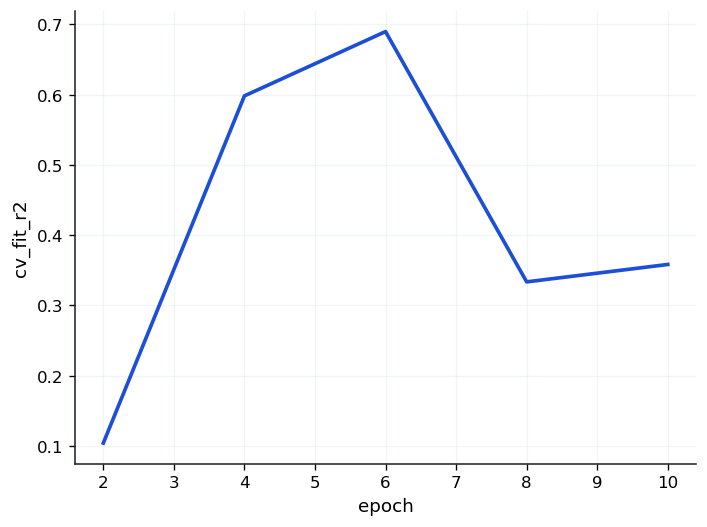

selected run: cv_transformer_mixed_sources
best cv_fit_r2= 0.6898053573932268 at epoch 6
best checkpoint: ../results/cv_transformer_mixed_sources/rollout_checkpoints/epoch_0006.pt


In [29]:
# Selected run: CV-fit over epochs.
run_dir = Path(common_cfg['output_root']) / cfg.run_name
stats = torch.load(run_dir / 'train_stats.pt', map_location='cpu', weights_only=False)

epochs = np.asarray(stats['epoch'], dtype=int)
cv_fit_r2 = np.asarray(stats['cv_fit_r2'], dtype=float)
mask_cv = np.isfinite(cv_fit_r2)

paper_caption('CV-fit trajectory over training epochs')
fig, ax = plt.subplots(figsize=(6.0, 4.5))
ax.plot(epochs[mask_cv], cv_fit_r2[mask_cv], '-', linewidth=2.2, color=PAPER_COLORS['blue'])
ax.set_xlabel('epoch')
ax.set_ylabel('cv_fit_r2')
style_axes(ax, xlabel='epoch', ylabel='cv_fit_r2')
plt.tight_layout()
plt.show()

best_i = int(np.nanargmax(cv_fit_r2))
best_epoch = int(epochs[best_i])
best_cv_fit_r2 = float(cv_fit_r2[best_i])
best_ckpt = run_dir / 'rollout_checkpoints' / f'epoch_{best_epoch:04d}.pt'
print('selected run:', cfg.run_name)
print('best cv_fit_r2=', best_cv_fit_r2, 'at epoch', best_epoch)
print('best checkpoint:', best_ckpt)



In [30]:
# Load model from the saved best CV-fit checkpoint.
output_root = Path(common_cfg['output_root'])
run_dir = output_root / cfg.run_name
cfg_dict = json.loads((run_dir / 'config.json').read_text())
cfg_dict.pop('split_info', None)
cfg_loaded = ExperimentConfig(**cfg_dict)

device = cfg_loaded.device

_train_data, val_data, test_data, split_info = resolve_dataset_splits(
    cfg_loaded.dataset_path,
    train_count=cfg_loaded.train_count,
    val_count=cfg_loaded.val_count,
    dataset_mixture=cfg_loaded.dataset_mixture,
    split_seed=cfg_loaded.split_seed,
    shuffle_within_source=cfg_loaded.shuffle_dataset_within_source,
    mix_holdout_across_sources=cfg_loaded.mix_holdout_across_sources,
)
split_info_df = pd.DataFrame(split_info)

init_frames = [val_data[0][i].to(device) for i in range(cfg_loaded.history + 1)]
init_graph = build_graph(input_graphs=init_frames).to(device)

model = create_model(
    model_type=cfg_loaded.model_type,
    init_graph=init_graph,
    pos_dim=cfg_loaded.pos_dim,
    hidden_size=cfg_loaded.hidden_size,
    n_layers=cfg_loaded.n_layers,
    extras=cfg_loaded.model_extras,
).to(device)

model.load_checkpoint(str(best_ckpt))

model.eval()
model.freeze_normalizers = True
for p in model.parameters():
    p.requires_grad = False
model_inputs_cls = resolve_model_inputs(cfg_loaded.model_type)

print('Loaded model:', cfg_loaded.model_type, 'device=', device)
print('Run dir:', run_dir)
print('Loaded best CV checkpoint:', best_ckpt)
print('best cv_fit_r2:', best_cv_fit_r2, 'epoch:', best_epoch)
print('effective token sizes:', cfg_loaded.model_extras['token_sizes'])
print(split_info_df.to_string(index=False))
print('validation sims:', len(val_data), '| test sims:', len(test_data))


Loaded model: cv_transformer device= cuda
Run dir: ../results/cv_transformer_mixed_sources
Loaded best CV checkpoint: ../results/cv_transformer_mixed_sources/rollout_checkpoints/epoch_0006.pt
best cv_fit_r2: 0.6898053573932268 epoch: 6
effective token sizes: [240, 120, 1]
  source                                                         path  total  train  val  test
De Pablo              ../data/2340_dePablo_networks_OOL_undirected.pt    100     19   21    60
    Reid ../data/data_aux_opt_lowT_448sims_noang_bidirect_filtered.pt     79     24   23    32
validation sims: 44 | test sims: 92


In [31]:
# Extract trajectory-level and frame-level CV tables for VAL and TEST.
import itertools

dataset_cache = {}


def cached_load_dataset(path):
    path = str(path)
    if path not in dataset_cache:
        dataset_cache[path] = load_dataset(path)
    return dataset_cache[path]


def source_id_rows_for_path(path):
    path = Path(path)
    sims = cached_load_dataset(path)
    meta_path = path.with_suffix('.json')
    if meta_path.exists():
        try:
            meta = json.loads(meta_path.read_text())
            kept = meta.get('kept_original_indices')
            if isinstance(kept, list) and len(kept) == len(sims):
                return [int(x) for x in kept]
        except Exception:
            pass
    return [int(i) for i in range(len(sims))]


def split_source_rows(cfg):
    if not cfg.dataset_mixture:
        total = len(cached_load_dataset(cfg.dataset_path))
        holdout_rows = [
            {
                'source': Path(cfg.dataset_path).stem,
                'source_sim_idx': int(i),
            }
            for i in range(int(cfg.train_count), total)
        ]
        val_rows = holdout_rows[: int(cfg.val_count)]
        test_rows = holdout_rows[int(cfg.val_count):]
        return val_rows, test_rows

    generator = None
    if cfg.shuffle_dataset_within_source:
        generator = torch.Generator()
        generator.manual_seed(0 if cfg.split_seed is None else int(cfg.split_seed))

    pooled_holdout = []
    for source_idx, spec in enumerate(cfg.dataset_mixture):
        sims = cached_load_dataset(spec['path'])
        source_ids = source_id_rows_for_path(spec['path'])
        order = list(range(len(sims)))
        if generator is not None:
            order = torch.randperm(len(sims), generator=generator).tolist()
        source_name = str(spec.get('name', f'source_{source_idx + 1}'))
        src_train = int(spec['train_count'])
        if cfg.mix_holdout_across_sources:
            for filtered_idx in order[src_train:]:
                pooled_holdout.append({'source': source_name, 'source_sim_idx': int(source_ids[filtered_idx])})
        else:
            src_val = int(spec['val_count'])
            for filtered_idx in order[src_train:src_train + src_val]:
                pooled_holdout.append({'source': source_name, 'source_sim_idx': int(source_ids[filtered_idx])})
            for filtered_idx in order[src_train + src_val:]:
                pooled_holdout.append({'source': source_name, 'source_sim_idx': int(source_ids[filtered_idx])})

    if cfg.mix_holdout_across_sources and generator is not None:
        order = torch.randperm(len(pooled_holdout), generator=generator).tolist()
        pooled_holdout = [pooled_holdout[i] for i in order]

    val_rows = pooled_holdout[: int(cfg.val_count)]
    test_rows = pooled_holdout[int(cfg.val_count):]
    return val_rows, test_rows


cv_summary_type = 'mean'  # or 'median'


def extract_cv_frames(sims, split_name, source_rows):
    rows = []
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            n_local = len(sim) - 1
            row_meta = source_rows[sim_idx] if sim_idx < len(source_rows) else {'source': 'unknown', 'source_sim_idx': sim_idx}
            source = row_meta['source']
            source_sim_idx = int(row_meta['source_sim_idx'])
            for t in range(cfg_loaded.history, n_local):
                frames = [sim[i].to(device) for i in range(t - cfg_loaded.history, t + 1)]
                if t > 0:
                    prev_pos = sim[t - 1].to(device).x[:, : cfg_loaded.pos_dim]
                    cur_pos = frames[-1].to(device).x[:, : cfg_loaded.pos_dim]
                    frames[-1].vel_state = cur_pos - prev_pos
                input_graph = build_graph(frames).to(device)
                cv = model.extract_cv(input_graph, is_training=False).squeeze(0).detach().cpu().numpy()
                row = {
                    'split': split_name,
                    'source': source,
                    'sim_idx': sim_idx,
                    'source_sim_idx': source_sim_idx,
                    't': int(t),
                    'frame_p_ratio': float(calc_p_ratio_box(sim, t)),
                    'final_p_ratio': float(calc_p_ratio_box(sim, -1)),
                }
                for i, value in enumerate(np.asarray(cv, dtype=float).reshape(-1), start=1):
                    row[f'cv_{i}'] = float(value)
                rows.append(row)
    return pd.DataFrame(rows)


def summarize_cv_frames(df_frames, summary_type):
    if df_frames.empty:
        return pd.DataFrame(columns=['split', 'source', 'sim_idx', 'source_sim_idx', 'num_frames_used', 'final_p_ratio'])
    cv_cols = [c for c in df_frames.columns if c.startswith('cv_')]
    group_cols = ['split', 'source', 'sim_idx', 'source_sim_idx']
    if summary_type == 'mean':
        pooled = df_frames.groupby(group_cols, as_index=False)[cv_cols].mean()
    else:
        pooled = df_frames.groupby(group_cols, as_index=False)[cv_cols].median()
    counts = df_frames.groupby(group_cols, as_index=False).size().rename(columns={'size': 'num_frames_used'})
    finals = df_frames.groupby(group_cols, as_index=False)['final_p_ratio'].first()
    out = pooled.merge(counts, on=group_cols, how='left').merge(finals, on=group_cols, how='left')
    rename_map = {col: f'cv_{summary_type}_{col.split("_")[1]}' for col in cv_cols}
    out = out.rename(columns=rename_map)
    return out.sort_values('sim_idx').reset_index(drop=True)


def fit_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2 or np.allclose(np.std(x), 0.0) or np.allclose(np.std(y), 0.0):
        return np.nan
    coeff = np.polyfit(x, y, deg=1)
    y_hat = coeff[0] * x + coeff[1]
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan


def cv_pratio_table(df, split_name, summary_type):
    rows = []
    prefix = f'cv_{summary_type}_'
    cv_cols = [c for c in df.columns if c.startswith(prefix)]
    y = df['final_p_ratio'].to_numpy(dtype=float)
    for col in cv_cols:
        x = df[col].to_numpy(dtype=float)
        rows.append({
            'split': split_name,
            'cv': col,
            'summary_type': summary_type,
            'pearson_r': float(np.corrcoef(x, y)[0, 1]) if len(x) >= 2 and not np.allclose(np.std(x), 0.0) else np.nan,
            'spearman_r': float(df[col].corr(df['final_p_ratio'], method='spearman')),
            'fit_r2': fit_r2(x, y),
        })
    out = pd.DataFrame(rows)
    out['abs_pearson_r'] = out['pearson_r'].abs()
    return out.sort_values('abs_pearson_r', ascending=False).reset_index(drop=True)


def fit_linear_combo(df_fit, feature_cols, target_col='final_p_ratio'):
    X = df_fit[feature_cols].to_numpy(dtype=float)
    y = df_fit[target_col].to_numpy(dtype=float)
    X_aug = np.column_stack([np.ones(len(X)), X])
    coef, *_ = np.linalg.lstsq(X_aug, y, rcond=None)
    return coef


def predict_linear_combo(df, feature_cols, coef, target_col='final_p_ratio'):
    X = df[feature_cols].to_numpy(dtype=float)
    X_aug = np.column_stack([np.ones(len(X)), X])
    pred = X_aug @ coef
    keep_cols = [col for col in ['source', 'sim_idx', 'source_sim_idx', 'num_frames_used', target_col] if col in df.columns]
    out = df[keep_cols].copy()
    out[f'pred_{target_col}'] = pred
    return out


def summarize_prediction_df(df_pred, split_name, target_col='final_p_ratio'):
    x = df_pred[target_col].to_numpy(dtype=float)
    y = df_pred[f'pred_{target_col}'].to_numpy(dtype=float)
    rmse = float(np.sqrt(np.mean((y - x) ** 2)))
    return {
        'split': split_name,
        'pearson_r': float(np.corrcoef(x, y)[0, 1]) if len(x) >= 2 and not np.allclose(np.std(y), 0.0) else np.nan,
        'spearman_r': float(pd.Series(x).corr(pd.Series(y), method='spearman')),
        'fit_r2': fit_r2(x, y),
        'rmse': rmse,
    }


def best_corr_linear_combo(df_fit, df_eval, feature_cols, target_col='final_p_ratio'):
    best = None
    for subset_size in range(1, len(feature_cols) + 1):
        for subset in itertools.combinations(feature_cols, subset_size):
            subset = list(subset)
            coef = fit_linear_combo(df_fit, subset, target_col=target_col)
            fit_pred_df = predict_linear_combo(df_fit, subset, coef, target_col=target_col)
            eval_pred_df = predict_linear_combo(df_eval, subset, coef, target_col=target_col)
            fit_stats = summarize_prediction_df(fit_pred_df, 'fit', target_col=target_col)
            eval_stats = summarize_prediction_df(eval_pred_df, 'eval', target_col=target_col)
            candidate = {
                'feature_cols': subset,
                'coef': coef,
                'fit_pred_df': fit_pred_df,
                'eval_pred_df': eval_pred_df,
                'fit_stats': fit_stats,
                'eval_stats': eval_stats,
            }
            key = (abs(eval_stats['pearson_r']), eval_stats['fit_r2'], -eval_stats['rmse'])
            if best is None or key > best['key']:
                best = {**candidate, 'key': key}
    return best


val_source_rows, test_source_rows = split_source_rows(cfg_loaded)
df_val_frames = extract_cv_frames(val_data, 'val', val_source_rows)
df_test_frames = extract_cv_frames(test_data, 'test', test_source_rows)
df_all_frames = pd.concat([df_val_frames, df_test_frames], ignore_index=True)
df_val = summarize_cv_frames(df_val_frames, cv_summary_type)
df_test = summarize_cv_frames(df_test_frames, cv_summary_type)

val_cv_table = cv_pratio_table(df_val, 'val', cv_summary_type)
test_cv_table = cv_pratio_table(df_test, 'test', cv_summary_type)

cv_prefix = f'cv_{cv_summary_type}_'
selected_cv_col = str(val_cv_table.iloc[0]['cv'])
selected_cv_idx = int(selected_cv_col.split('_')[-1]) - 1
pooled_cv_cols = [c for c in df_val.columns if c.startswith(cv_prefix)]
linear_combo_payload = None
linear_combo_summary_df = pd.DataFrame()
if len(pooled_cv_cols) > 1:
    best_combo = best_corr_linear_combo(df_val, df_test, pooled_cv_cols, target_col='final_p_ratio')
    linear_combo_payload = {
        'feature_cols': best_combo['feature_cols'],
        'coef': best_combo['coef'],
        'val_pred_df': best_combo['fit_pred_df'].rename(columns={'pred_final_p_ratio': 'pred_final_p_ratio'}),
        'test_pred_df': best_combo['eval_pred_df'].rename(columns={'pred_final_p_ratio': 'pred_final_p_ratio'}),
    }
    linear_combo_summary_df = pd.DataFrame([
        {**best_combo['fit_stats'], 'split': 'val'},
        {**best_combo['eval_stats'], 'split': 'test'},
    ])
    linear_combo_summary_df['feature_cols'] = ', '.join(best_combo['feature_cols'])

print('CV summary type:', cv_summary_type)
print('selected CV for plots:', selected_cv_col, '(index:', selected_cv_idx, ')')
print(val_cv_table[['summary_type', 'cv', 'pearson_r', 'spearman_r', 'fit_r2']])
if linear_combo_payload is not None:
    print('best pooled linear combination by validation correlation:')
    print(', '.join(linear_combo_payload['feature_cols']))
    display(linear_combo_summary_df.round(4))







CV summary type: mean
selected CV for plots: cv_mean_1 (index: 0 )
  summary_type         cv  pearson_r  spearman_r    fit_r2
0         mean  cv_mean_1   0.830545    0.805215  0.689805


Frame-level CV correlation matrix


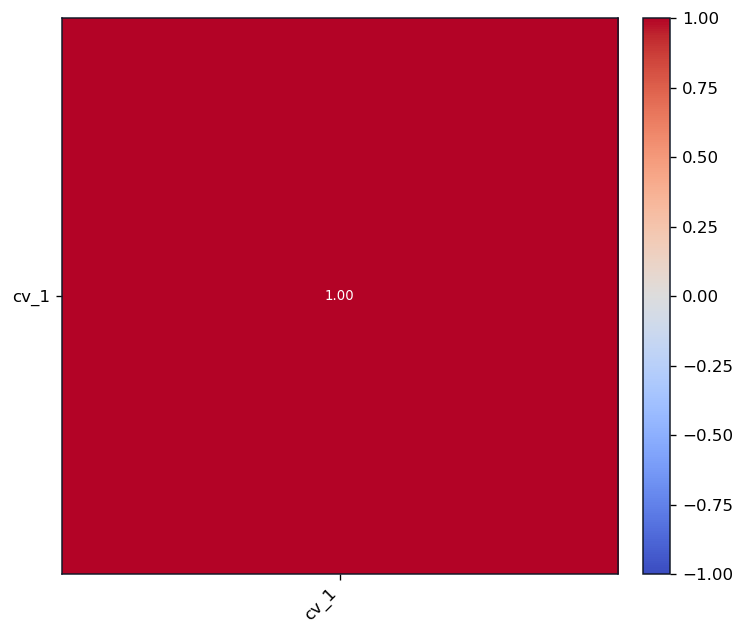

,cv_1
cv_1,1.0


In [32]:
# Frame-level CV correlation matrix.
frame_cv_cols = [c for c in df_all_frames.columns if c.startswith('cv_')]
frame_cv_corr = df_all_frames[frame_cv_cols].corr(method='pearson')

paper_caption('Frame-level CV correlation matrix')
fig, ax = plt.subplots(figsize=(6.2, 5.4))
im = ax.imshow(frame_cv_corr.to_numpy(dtype=float), vmin=-1.0, vmax=1.0, cmap='coolwarm')
ax.set_xticks(range(len(frame_cv_cols)))
ax.set_yticks(range(len(frame_cv_cols)))
ax.set_xticklabels(frame_cv_cols, rotation=45, ha='right')
ax.set_yticklabels(frame_cv_cols)
for i in range(len(frame_cv_cols)):
    for j in range(len(frame_cv_cols)):
        val = float(frame_cv_corr.iat[i, j])
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(val) > 0.55 else 'black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

display(frame_cv_corr.round(3))



Best single-CV versus final p-ratio on validation split


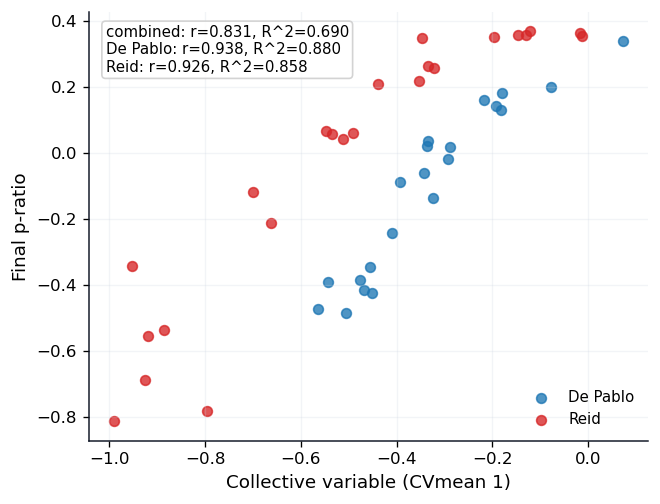

Best single-CV versus final p-ratio on test split


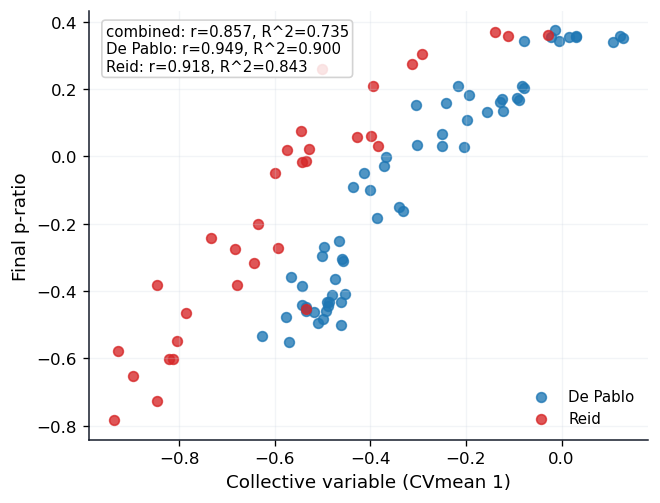

Potential test outliers for current split:


,source,sim_idx,source_sim_idx,cv_mean_1,final_p_ratio,abs_fit_residual
0,Reid,40,42,-0.5013,0.2594,0.4820
1,Reid,48,72,-0.5451,0.0762,0.3468
2,Reid,56,45,-0.5754,0.0205,0.3243
3,De Pablo,49,71,-0.4613,-0.5008,0.3219
4,Reid,28,87,-0.3954,0.2091,0.3158
5,Reid,39,21,-0.2911,0.3044,0.2969
6,Reid,50,14,-0.3139,0.2746,0.2922
7,Reid,52,15,-0.6004,-0.0504,0.2808
8,Reid,14,62,-0.5279,0.0207,0.2726
9,De Pablo,64,73,-0.5088,-0.4949,0.2640


saved: ../results/cv_transformer_mixed_sources/cv_transformer_val_selected_cv_vs_pratio.csv
saved: ../results/cv_transformer_mixed_sources/cv_transformer_test_selected_cv_vs_pratio.csv
saved: ../results/cv_transformer_mixed_sources/cv_transformer_test_all_cv_vs_pratio.csv
saved: ../results/cv_transformer_mixed_sources/cv_transformer_test_selected_cv_outliers.csv


In [33]:
# Selected CV vs final p-ratio on VAL and TEST.
plot_cv_col = selected_cv_col
plot_cv_label = plot_cv_col.replace('cv_', 'CV').replace('_', ' ')
source_palette = {
    'De Pablo': '#1f77b4',
    'Reid': '#d62728',
    'unknown': '#6b7280',
}


def single_cv_outlier_df(df):
    x = df[plot_cv_col].to_numpy(dtype=float)
    y = df['final_p_ratio'].to_numpy(dtype=float)
    if len(x) < 2 or np.allclose(np.std(x), 0.0):
        y_hat = np.full_like(y, np.nan, dtype=float)
    else:
        coeff = np.polyfit(x, y, deg=1)
        y_hat = coeff[0] * x + coeff[1]
    keep_cols = [c for c in ['source', 'sim_idx', 'source_sim_idx', 'num_frames_used', plot_cv_col, 'final_p_ratio'] if c in df.columns]
    out = df[keep_cols].copy()
    out['fit_pred_final_p_ratio'] = y_hat
    out['fit_residual'] = y - y_hat
    out['abs_fit_residual'] = np.abs(out['fit_residual'])
    return out.sort_values('abs_fit_residual', ascending=False).reset_index(drop=True)


def scatter_panel(ax, df):
    x = df[plot_cv_col].to_numpy(dtype=float)
    y = df['final_p_ratio'].to_numpy(dtype=float)
    r = float(np.corrcoef(x, y)[0, 1]) if len(x) >= 2 and not np.allclose(np.std(x), 0.0) else np.nan
    r2 = fit_r2(x, y)
    stat_lines = [f'combined: r={r:.3f}, R^2={r2:.3f}']
    for source_name, sub in df.groupby('source'):
        color = source_palette.get(source_name, '#6b7280')
        ax.scatter(sub[plot_cv_col], sub['final_p_ratio'], s=34, alpha=0.78, color=color, label=source_name)
        xs = sub[plot_cv_col].to_numpy(dtype=float)
        ys = sub['final_p_ratio'].to_numpy(dtype=float)
        if len(xs) >= 2 and not np.allclose(xs.std(), 0.0):
            source_r = float(np.corrcoef(xs, ys)[0, 1])
            source_r2 = fit_r2(xs, ys)
            stat_lines.append(f'{source_name}: r={source_r:.3f}, R^2={source_r2:.3f}')
        else:
            stat_lines.append(f'{source_name}: not enough spread')
    ax.text(
        0.03, 0.97,
        '\n'.join(stat_lines),
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='0.8'),
    )
    style_axes(ax, xlabel=f'Collective variable ({plot_cv_label})', ylabel='Final p-ratio', legend=True)


paper_caption('Best single-CV versus final p-ratio on validation split')
fig, ax = plt.subplots(1, 1, figsize=(5.6, 4.3))
scatter_panel(ax, df_val)
plt.tight_layout()
plt.show()

paper_caption('Best single-CV versus final p-ratio on test split')
fig, ax = plt.subplots(1, 1, figsize=(5.6, 4.3))
scatter_panel(ax, df_test)
plt.tight_layout()
plt.show()

val_csv = run_dir / 'cv_transformer_val_selected_cv_vs_pratio.csv'
test_csv = run_dir / 'cv_transformer_test_selected_cv_vs_pratio.csv'
test_table_csv = run_dir / 'cv_transformer_test_all_cv_vs_pratio.csv'
outlier_csv = run_dir / 'cv_transformer_test_selected_cv_outliers.csv'
df_val[['source', 'sim_idx', 'source_sim_idx', 'num_frames_used', plot_cv_col, 'final_p_ratio']].to_csv(val_csv, index=False)
df_test[['source', 'sim_idx', 'source_sim_idx', 'num_frames_used', plot_cv_col, 'final_p_ratio']].to_csv(test_csv, index=False)
test_cv_table.to_csv(test_table_csv, index=False)
outlier_df = single_cv_outlier_df(df_test)
outlier_df.to_csv(outlier_csv, index=False)
print('Potential test outliers for current split:')
display(outlier_df[[c for c in ['source', 'sim_idx', 'source_sim_idx', plot_cv_col, 'final_p_ratio', 'abs_fit_residual'] if c in outlier_df.columns]].head(12).round(4))
print('saved:', val_csv)
print('saved:', test_csv)
print('saved:', test_table_csv)
print('saved:', outlier_csv)

if linear_combo_payload is not None:
    def combo_scatter_panel(ax, pred_df):
        x = pred_df['final_p_ratio'].to_numpy(dtype=float)
        y = pred_df['pred_final_p_ratio'].to_numpy(dtype=float)
        r = float(np.corrcoef(x, y)[0, 1]) if len(x) >= 2 and not np.allclose(np.std(y), 0.0) else np.nan
        r2 = fit_r2(x, y)
        rmse = float(np.sqrt(np.mean((y - x) ** 2)))
        for source_name, sub in pred_df.groupby('source'):
            color = source_palette.get(source_name, '#6b7280')
            ax.scatter(sub['final_p_ratio'], sub['pred_final_p_ratio'], s=42, alpha=0.82, color=color, label=source_name)
        lo = float(min(np.min(x), np.min(y)))
        hi = float(max(np.max(x), np.max(y)))
        pad = 0.05 * (hi - lo + 1e-8)
        lims = (lo - pad, hi + pad)
        ax.plot(lims, lims, color='black', ls='--', lw=1.0)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        print(f'r={r:.3f}, R^2={r2:.3f}, RMSE={rmse:.3f}')
        style_axes(ax, xlabel='True final p-ratio', ylabel='Predicted final p-ratio', legend=True)

    paper_caption('Best pooled linear combination versus final p-ratio on validation split')
    fig, ax = plt.subplots(1, 1, figsize=(5.6, 4.3))
    combo_scatter_panel(ax, linear_combo_payload['val_pred_df'])
    plt.tight_layout()
    plt.show()

    paper_caption('Best pooled linear combination versus final p-ratio on test split')
    fig, ax = plt.subplots(1, 1, figsize=(5.6, 4.3))
    combo_scatter_panel(ax, linear_combo_payload['test_pred_df'])
    plt.tight_layout()
    plt.show()




Representative single-trajectory CV behavior for auxetic and non-auxetic networks from each source
De Pablo | Auxetic | source_sim_idx=76 | final p-ratio=-0.553
De Pablo | Non-auxetic | source_sim_idx=15 | final p-ratio=0.021
Reid | Auxetic | source_sim_idx=12 | final p-ratio=-0.812
Reid | Non-auxetic | source_sim_idx=45 | final p-ratio=0.021


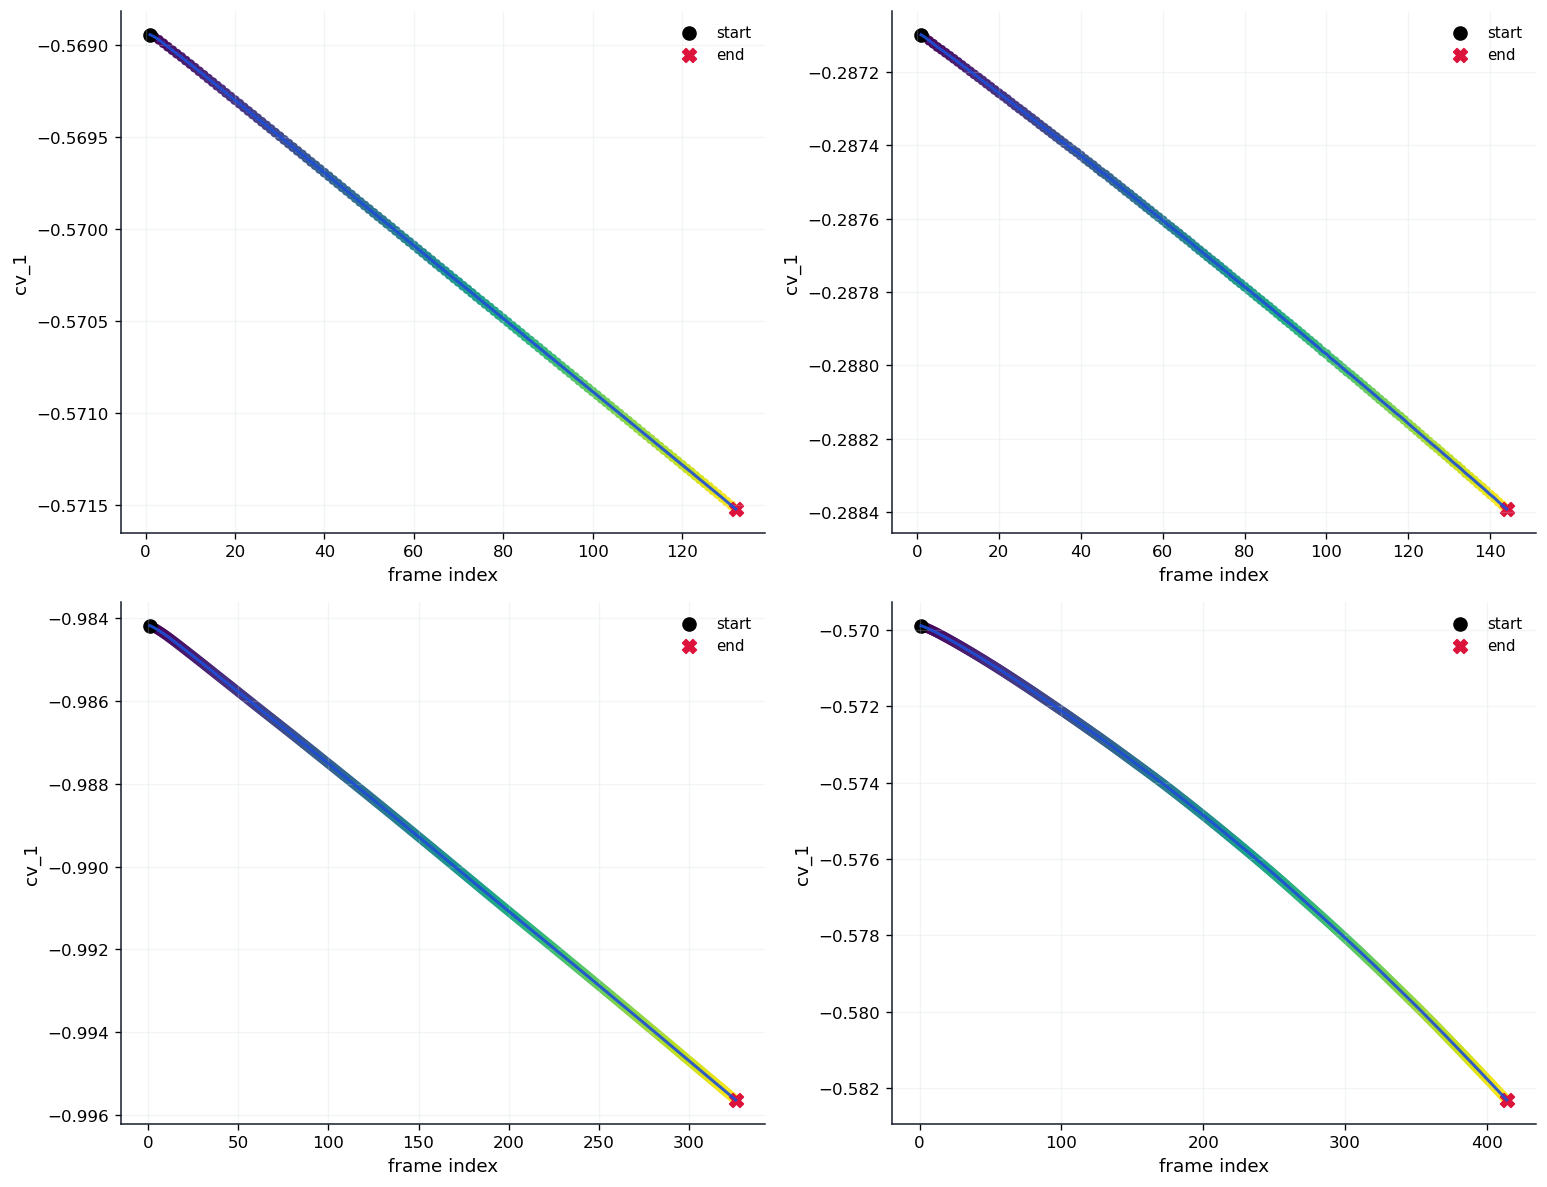

In [34]:
# Selected CV trajectory examples from each source.
available_frame_cv_cols = sorted([c for c in df_all_frames.columns if c.startswith('cv_')], key=lambda x: int(x.split('_')[1]))
selected_frame_cv_col = f'cv_{selected_cv_idx + 1}'
source_order = ['De Pablo', 'Reid']
use_cv_pair = len(available_frame_cv_cols) >= 2
other_cv_col = next((c for c in available_frame_cv_cols if c != selected_frame_cv_col), selected_frame_cv_col)
id_col = 'source_sim_idx' if 'source_sim_idx' in df_all_frames.columns else 'sim_idx'

traj_sign_cols = ['split', 'source', 'sim_idx', 'final_p_ratio']
if 'source_sim_idx' in df_all_frames.columns:
    traj_sign_cols.insert(3, 'source_sim_idx')
traj_sign_df = (
    df_all_frames[traj_sign_cols]
    .drop_duplicates(subset=['split', 'source', id_col])
    .sort_values(['source', 'final_p_ratio', id_col])
    .reset_index(drop=True)
)

example_rows = []
for source_name in source_order:
    source_df = traj_sign_df[traj_sign_df['source'] == source_name].copy()
    auxetic_row = source_df[source_df['final_p_ratio'] < 0].head(1)
    non_auxetic_row = source_df[source_df['final_p_ratio'] >= 0].head(1)
    if len(auxetic_row):
        example_rows.append(('Auxetic', auxetic_row.iloc[0]))
    if len(non_auxetic_row):
        example_rows.append(('Non-auxetic', non_auxetic_row.iloc[0]))

paper_caption('Representative single-trajectory CV behavior for auxetic and non-auxetic networks from each source')
fig, axes = plt.subplots(2, 2, figsize=(13.0, 10.0))
axes = np.asarray(axes).reshape(-1)
for ax, (label, row) in zip(axes, example_rows):
    subset = df_all_frames[
        (df_all_frames['split'] == row['split'])
        & (df_all_frames['source'] == row['source'])
        & (df_all_frames[id_col] == row[id_col])
    ].copy().sort_values('t')
    if use_cv_pair:
        x = subset[selected_frame_cv_col].to_numpy(dtype=float)
        y = subset[other_cv_col].to_numpy(dtype=float)
        ax.plot(x, y, color=PAPER_COLORS['blue'], alpha=0.9, linewidth=1.8)
        ax.scatter(x, y, c=subset['t'], cmap='viridis', s=24, alpha=0.95)
        ax.scatter(x[0], y[0], color='black', s=60, marker='o', label='start')
        ax.scatter(x[-1], y[-1], color='crimson', s=68, marker='X', label='end')
        pad_x = 0.08 * (np.nanmax(x) - np.nanmin(x) + 1e-8)
        pad_y = 0.08 * (np.nanmax(y) - np.nanmin(y) + 1e-8)
        ax.set_xlim(np.nanmin(x) - pad_x, np.nanmax(x) + pad_x)
        ax.set_ylim(np.nanmin(y) - pad_y, np.nanmax(y) + pad_y)
        style_axes(ax, xlabel=selected_frame_cv_col, ylabel=other_cv_col, legend=True)
    else:
        x = subset['t'].to_numpy(dtype=float)
        y = subset[selected_frame_cv_col].to_numpy(dtype=float)
        ax.plot(x, y, color=PAPER_COLORS['blue'], alpha=0.9, linewidth=1.8)
        ax.scatter(x, y, c=subset['t'], cmap='viridis', s=24, alpha=0.95)
        ax.scatter(x[0], y[0], color='black', s=60, marker='o', label='start')
        ax.scatter(x[-1], y[-1], color='crimson', s=68, marker='X', label='end')
        style_axes(ax, xlabel='frame index', ylabel=selected_frame_cv_col, legend=True)
    print(f"{row['source']} | {label} | {id_col}={int(row[id_col])} | final p-ratio={float(row['final_p_ratio']):.3f}")
for ax in axes[len(example_rows):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


Single-CV trajectories over frame index
VAL panel: cv_1 over trajectory.
TEST panel: cv_1 over trajectory.


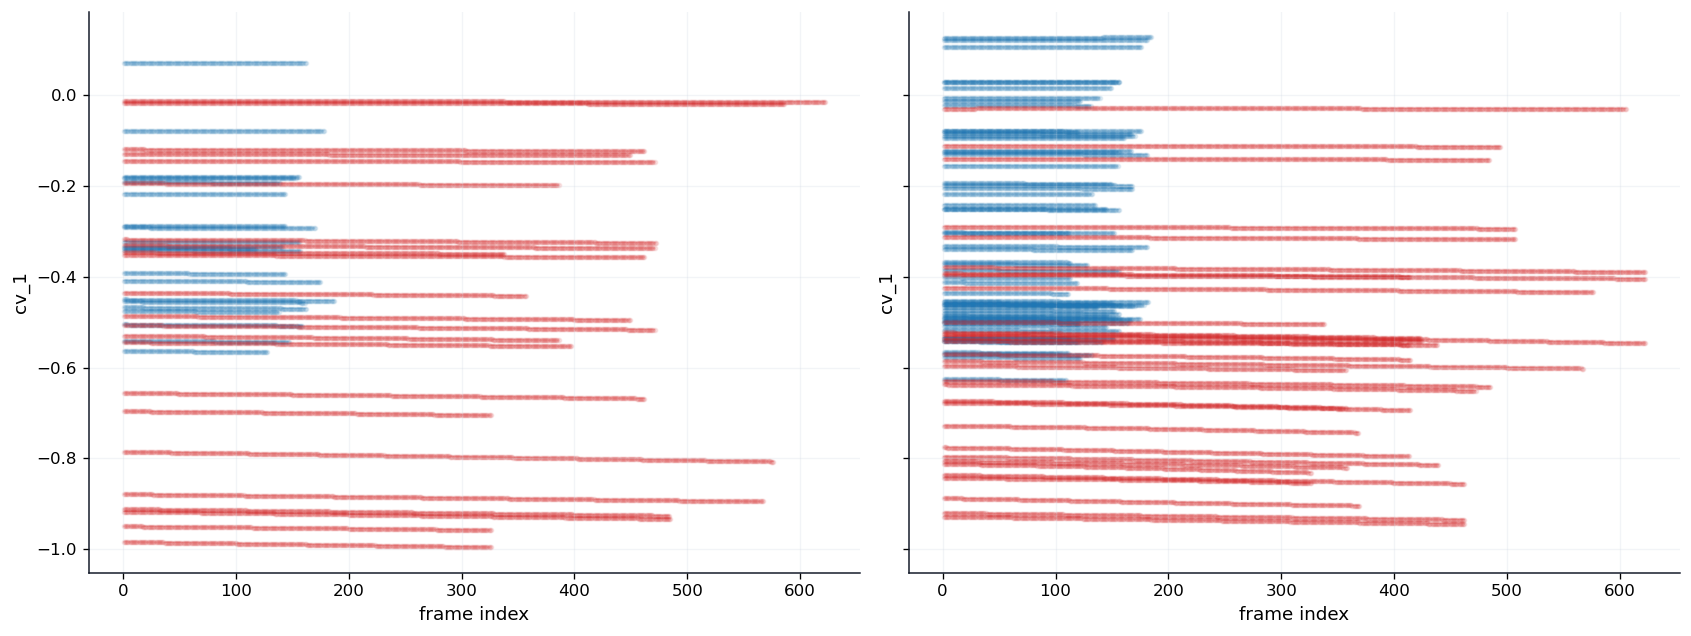

In [35]:
# Trajectory map in CV space or along the selected single CV.
available_frame_cv_cols = sorted([c for c in df_all_frames.columns if c.startswith('cv_')], key=lambda x: int(x.split('_')[1]))
frame_cv_col = f'cv_{selected_cv_idx + 1}'
use_cv_pair = len(available_frame_cv_cols) >= 2
frame_other_cv_col = next((c for c in available_frame_cv_cols if c != frame_cv_col), frame_cv_col)

if use_cv_pair:
    traj_cv_x = frame_cv_col
    traj_cv_y = frame_other_cv_col

    paper_caption('Frame-wise trajectory paths in learned CV space')
    fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.8), sharex=True, sharey=True)
    for ax, split_name, split_df in zip(axes, ['val', 'test'], [df_val_frames, df_test_frames]):
        for (source_name, sim_idx), sub in split_df.groupby(['source', 'sim_idx']):
            sub = sub.sort_values('t')
            color = source_palette.get(source_name, '#6b7280')
            ax.plot(sub[traj_cv_x], sub[traj_cv_y], color=color, alpha=0.18, lw=0.9)
            ax.scatter(sub[traj_cv_x], sub[traj_cv_y], color=color, alpha=0.08, s=6)
        for source_name in split_df['source'].dropna().unique():
            color = source_palette.get(source_name, '#6b7280')
            sub = split_df[split_df['source'].eq(source_name)]
            centroid_x = float(sub[traj_cv_x].mean())
            centroid_y = float(sub[traj_cv_y].mean())
            ax.scatter([centroid_x], [centroid_y], color=color, s=90, edgecolor='black', linewidth=0.6, label=source_name)
        print(f'{split_name.upper()} panel: trajectory paths in {traj_cv_x} / {traj_cv_y}.')
        style_axes(ax, xlabel=traj_cv_x, ylabel=traj_cv_y, legend=True)
    plt.tight_layout()
    plt.show()

    paper_caption('All validation and test trajectories in learned CV space')
    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    for (split_name, source_name, sim_idx), sub in df_all_frames.groupby(['split', 'source', 'sim_idx']):
        sub = sub.sort_values('t')
        color = source_palette.get(source_name, '#6b7280')
        ax.plot(sub[traj_cv_x], sub[traj_cv_y], color=color, alpha=0.10, lw=0.75)
    ax.scatter(df_all_frames[traj_cv_x], df_all_frames[traj_cv_y], c=df_all_frames['t'], cmap='viridis', s=4, alpha=0.12)
    style_axes(ax, xlabel=traj_cv_x, ylabel=traj_cv_y)
    plt.tight_layout()
    plt.show()

    traj_map_csv = run_dir / 'cv_transformer_cv_trajectory_map.csv'
    df_all_frames[['split', 'source', 'sim_idx', 't', traj_cv_x, traj_cv_y, 'frame_p_ratio']].to_csv(traj_map_csv, index=False)
    print('saved:', traj_map_csv)
else:
    paper_caption('Single-CV trajectories over frame index')
    fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.4), sharey=True)
    for ax, split_name, split_df in zip(axes, ['val', 'test'], [df_val_frames, df_test_frames]):
        for (source_name, sim_idx), sub in split_df.groupby(['source', 'sim_idx']):
            sub = sub.sort_values('t')
            color = source_palette.get(source_name, '#6b7280')
            ax.plot(sub['t'], sub[frame_cv_col], color=color, alpha=0.20, lw=0.9)
            ax.scatter(sub['t'], sub[frame_cv_col], color=color, alpha=0.10, s=6)
        print(f'{split_name.upper()} panel: {frame_cv_col} over trajectory.')
        style_axes(ax, xlabel='frame index', ylabel=frame_cv_col)
    plt.tight_layout()
    plt.show()




In [36]:
# Source-specific effect of one CV after accounting for another available CV.
cv_cols_all = sorted([c for c in df_all_frames.columns if c.startswith('cv_')], key=lambda x: int(x.split('_')[1]))
if len(cv_cols_all) < 2:
    print('Skipping source-specific incremental analysis: only one CV is available.')
else:
    secondary_cv_col = 'cv_1'
    primary_cv_col = 'cv_2' if len(cv_cols_all) >= 2 else 'cv_1'
    analysis_df = df_all_frames[['source', 'sim_idx', 'frame_p_ratio', secondary_cv_col, primary_cv_col]].copy().dropna().reset_index(drop=True)

    def linear_fit_stats(df, feature_cols, target_col='frame_p_ratio'):
        X = df[feature_cols].to_numpy(dtype=float)
        y = df[target_col].to_numpy(dtype=float)
        X_aug = np.column_stack([np.ones(len(X)), X])
        coef, *_ = np.linalg.lstsq(X_aug, y, rcond=None)
        pred = X_aug @ coef
        resid = y - pred
        ss_res = float(np.sum(resid ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
        rmse_val = float(np.sqrt(np.mean((y - pred) ** 2)))
        return coef, pred, resid, r2, rmse_val

    rows = []
    residual_rows = []
    for source_name, sub in analysis_df.groupby('source'):
        coef_a, pred_a, resid_a, r2_a, rmse_a = linear_fit_stats(sub, [primary_cv_col])
        coef_ab, pred_ab, resid_ab, r2_ab, rmse_ab = linear_fit_stats(sub, [primary_cv_col, secondary_cv_col])
        resid_secondary_r = float(np.corrcoef(sub[secondary_cv_col].to_numpy(dtype=float), resid_a)[0, 1]) if len(sub) >= 2 else np.nan
        rows.append({
            'source': source_name,
            'n_frames': int(len(sub)),
            f'r2_{primary_cv_col}_only': r2_a,
            f'rmse_{primary_cv_col}_only': rmse_a,
            f'r2_{primary_cv_col}_plus_{secondary_cv_col}': r2_ab,
            f'rmse_{primary_cv_col}_plus_{secondary_cv_col}': rmse_ab,
            f'delta_r2_from_{secondary_cv_col}': r2_ab - r2_a,
            f'delta_rmse_from_{secondary_cv_col}': rmse_ab - rmse_a,
            f'residual_corr_{secondary_cv_col}_after_{primary_cv_col}': resid_secondary_r,
            f'coef_{primary_cv_col}_only': float(coef_a[1]),
            f'coef_{primary_cv_col}_plus_{secondary_cv_col}_{primary_cv_col}': float(coef_ab[1]),
            f'coef_{primary_cv_col}_plus_{secondary_cv_col}_{secondary_cv_col}': float(coef_ab[2]),
        })
        residual_rows.append(pd.DataFrame({
            'source': source_name,
            secondary_cv_col: sub[secondary_cv_col].to_numpy(dtype=float),
            f'residual_after_{primary_cv_col}': resid_a,
        }))

    source_increment_df = pd.DataFrame(rows).reset_index(drop=True)
    residual_df = pd.concat(residual_rows, ignore_index=True)
    display(source_increment_df.round(4))

    paper_caption('Residual contribution of the second CV after regressing out the primary CV')
    fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.2), sharey=True)
    for ax, source_name in zip(axes, ['De Pablo', 'Reid']):
        sub = residual_df[residual_df['source'].eq(source_name)]
        color = source_palette.get(source_name, '#6b7280')
        ax.scatter(sub[secondary_cv_col], sub[f'residual_after_{primary_cv_col}'], s=10, alpha=0.18, color=color)
        x = sub[secondary_cv_col].to_numpy(dtype=float)
        y = sub[f'residual_after_{primary_cv_col}'].to_numpy(dtype=float)
        if len(sub) >= 2 and not np.allclose(x.std(), 0.0):
            slope, intercept = np.polyfit(x, y, deg=1)
            xx = np.linspace(float(np.min(x)), float(np.max(x)), 200)
            ax.plot(xx, slope * xx + intercept, color='black', lw=1.4, ls='--')
            r = float(np.corrcoef(x, y)[0, 1])
        else:
            r = np.nan
        print(f'{source_name}: residual after regressing out {primary_cv_col}.')
        style_axes(ax, xlabel=secondary_cv_col, ylabel=f'Residual(frame p-ratio | {primary_cv_col})')
        ax.text(
            0.03, 0.97,
            f'r = {r:.3f} frames = {len(sub):,}',
            transform=ax.transAxes,
            va='top', ha='left', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.88, edgecolor='0.8'),
        )
    plt.tight_layout()
    plt.show()





Skipping source-specific incremental analysis: only one CV is available.


### CV Versus X/Y Collapse


best CV for delta_width_x: cv_mean_1
          cv  pearson_r  spearman_r    fit_r2
0  cv_mean_1   0.199612    0.126286  0.039845
best CV for delta_width_y: cv_mean_1
          cv  pearson_r  spearman_r    fit_r2
0  cv_mean_1   0.817531    0.789993  0.668356
Best single-CV correlations with x-width and y-width change
Best CV vs x-width change


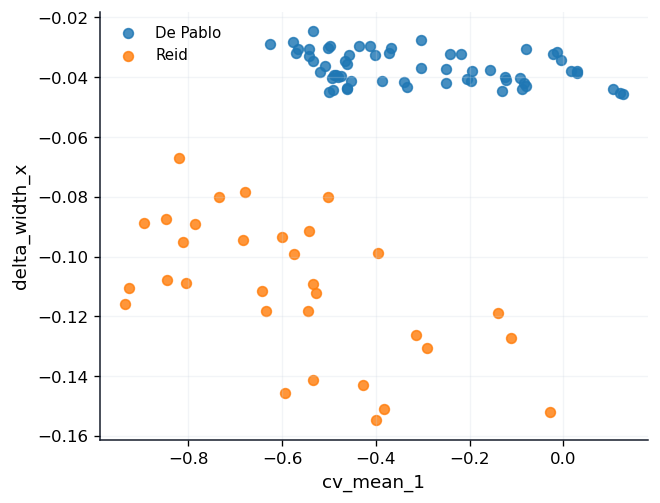

Best CV vs y-width change


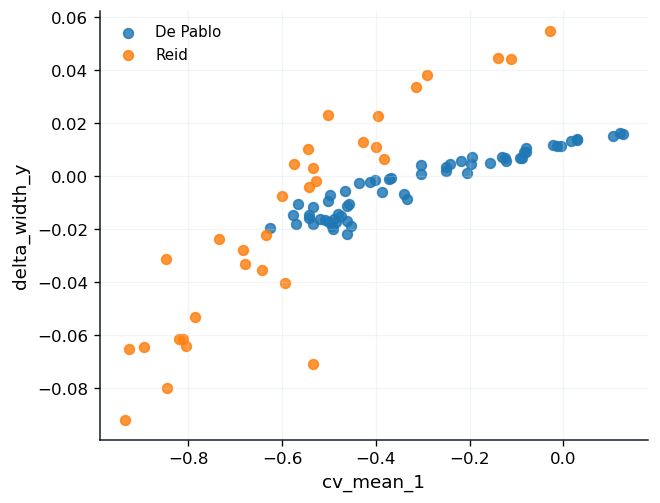

Skipping CV-vs-CV sign plot: both axis-collapse targets selected cv_1.


In [37]:
# Per-trajectory width-collapse summaries and CV correlations.

def trajectory_axis_collapse_rows(sims, split_name, source_rows):
    rows = []
    for sim_idx, sim in enumerate(sims):
        row_meta = source_rows[sim_idx] if sim_idx < len(source_rows) else {'source': 'unknown', 'source_sim_idx': sim_idx}
        first_pos = sim[cfg_loaded.history].x[:, : cfg_loaded.pos_dim].detach().cpu().numpy()
        last_pos = sim[-1].x[:, : cfg_loaded.pos_dim].detach().cpu().numpy()
        first_centered = first_pos - first_pos.mean(axis=0, keepdims=True)
        last_centered = last_pos - last_pos.mean(axis=0, keepdims=True)
        width_x_0 = float(np.mean(np.abs(first_centered[:, 0])))
        width_y_0 = float(np.mean(np.abs(first_centered[:, 1]))) if first_centered.shape[1] > 1 else np.nan
        width_x_1 = float(np.mean(np.abs(last_centered[:, 0])))
        width_y_1 = float(np.mean(np.abs(last_centered[:, 1]))) if last_centered.shape[1] > 1 else np.nan
        rows.append({
            'split': split_name,
            'source': row_meta['source'],
            'source_sim_idx': int(row_meta['source_sim_idx']),
            'sim_idx': sim_idx,
            'delta_width_x': width_x_1 - width_x_0,
            'delta_width_y': width_y_1 - width_y_0,
        })
    return pd.DataFrame(rows)


def best_cv_for_target(df, target_col, summary_type):
    prefix = f'cv_{summary_type}_'
    cv_cols = [c for c in df.columns if c.startswith(prefix)]
    rows = []
    for col in cv_cols:
        x = df[col].to_numpy(dtype=float)
        y = df[target_col].to_numpy(dtype=float)
        rows.append({
            'target': target_col,
            'cv': col,
            'pearson_r': float(np.corrcoef(x, y)[0, 1]) if len(x) >= 2 and not np.allclose(np.std(x), 0.0) else np.nan,
            'spearman_r': float(pd.Series(x).corr(pd.Series(y), method='spearman')),
            'fit_r2': fit_r2(x, y),
        })
    out = pd.DataFrame(rows)
    out['abs_pearson_r'] = out['pearson_r'].abs()
    return out.sort_values('abs_pearson_r', ascending=False).reset_index(drop=True)

axis_val_df = trajectory_axis_collapse_rows(val_data, 'val', val_source_rows)
axis_test_df = trajectory_axis_collapse_rows(test_data, 'test', test_source_rows)
axis_all_df = pd.concat([axis_val_df, axis_test_df], ignore_index=True)
summary_id_col = 'source_sim_idx' if 'source_sim_idx' in df_val.columns and 'source_sim_idx' in axis_val_df.columns else 'sim_idx'
merge_cols = ['split', 'source', 'sim_idx'] + ([summary_id_col] if summary_id_col != 'sim_idx' else [])
cv_axis_val_df = df_val.merge(axis_val_df, on=merge_cols, how='left')
cv_axis_test_df = df_test.merge(axis_test_df, on=merge_cols, how='left')

best_x_table = best_cv_for_target(cv_axis_val_df, 'delta_width_x', cv_summary_type)
best_y_table = best_cv_for_target(cv_axis_val_df, 'delta_width_y', cv_summary_type)
best_x_cv = str(best_x_table.iloc[0]['cv'])
best_y_cv = str(best_y_table.iloc[0]['cv'])

print('best CV for delta_width_x:', best_x_cv)
print(best_x_table[['cv', 'pearson_r', 'spearman_r', 'fit_r2']].head(5))
print('best CV for delta_width_y:', best_y_cv)
print(best_y_table[['cv', 'pearson_r', 'spearman_r', 'fit_r2']].head(5))


if len([c for c in cv_axis_val_df.columns if c.startswith(f'cv_{cv_summary_type}_')]) > 1:
    best_x_combo = best_corr_linear_combo(cv_axis_val_df, cv_axis_test_df, [c for c in cv_axis_val_df.columns if c.startswith(f'cv_{cv_summary_type}_')], target_col='delta_width_x')
    best_y_combo = best_corr_linear_combo(cv_axis_val_df, cv_axis_test_df, [c for c in cv_axis_val_df.columns if c.startswith(f'cv_{cv_summary_type}_')], target_col='delta_width_y')
    combo_axis_summary_df = pd.DataFrame([
        {
            'target': 'delta_width_x',
            'feature_cols': ', '.join(best_x_combo['feature_cols']),
            'val_pearson_r': best_x_combo['fit_stats']['pearson_r'],
            'val_spearman_r': best_x_combo['fit_stats']['spearman_r'],
            'val_fit_r2': best_x_combo['fit_stats']['fit_r2'],
            'test_pearson_r': best_x_combo['eval_stats']['pearson_r'],
            'test_spearman_r': best_x_combo['eval_stats']['spearman_r'],
            'test_fit_r2': best_x_combo['eval_stats']['fit_r2'],
        },
        {
            'target': 'delta_width_y',
            'feature_cols': ', '.join(best_y_combo['feature_cols']),
            'val_pearson_r': best_y_combo['fit_stats']['pearson_r'],
            'val_spearman_r': best_y_combo['fit_stats']['spearman_r'],
            'val_fit_r2': best_y_combo['fit_stats']['fit_r2'],
            'test_pearson_r': best_y_combo['eval_stats']['pearson_r'],
            'test_spearman_r': best_y_combo['eval_stats']['spearman_r'],
            'test_fit_r2': best_y_combo['eval_stats']['fit_r2'],
        },
    ])
    print('best pooled linear combinations for width-change targets:')
    display(combo_axis_summary_df.round(4))


paper_caption('Best single-CV correlations with x-width and y-width change')
for cv_col, target_col, title in [
    (best_x_cv, 'delta_width_x', 'Best CV vs x-width change'),
    (best_y_cv, 'delta_width_y', 'Best CV vs y-width change'),
]:
    paper_caption(title)
    fig, ax = plt.subplots(1, 1, figsize=(5.6, 4.3))
    for source_name, source_df in cv_axis_test_df.groupby('source'):
        ax.scatter(source_df[cv_col], source_df[target_col], s=34, alpha=0.82, label=source_name)
    style_axes(ax, xlabel=cv_col, ylabel=target_col, legend=True)
    plt.tight_layout()
    plt.show()

best_x_idx = int(best_x_cv.split('_')[-1]) - 1
best_y_idx = int(best_y_cv.split('_')[-1]) - 1
best_x_frame_col = f'cv_{best_x_idx + 1}'
best_y_frame_col = f'cv_{best_y_idx + 1}'

if best_x_frame_col == best_y_frame_col:
    print(f'Skipping CV-vs-CV sign plot: both axis-collapse targets selected {best_x_frame_col}.')
else:
    frame_xy_plot_df = df_all_frames.copy()
    frame_id_col = 'source_sim_idx' if 'source_sim_idx' in frame_xy_plot_df.columns else 'sim_idx'
    traj_sign_cols = ['split', 'source', 'sim_idx', 'final_p_ratio']
    if frame_id_col != 'sim_idx':
        traj_sign_cols.insert(3, frame_id_col)
    traj_sign_df = (
        frame_xy_plot_df[traj_sign_cols]
        .drop_duplicates(subset=['split', 'source', frame_id_col])
        .assign(pratio_sign=lambda d: np.where(d['final_p_ratio'] < 0, 'negative final p-ratio', 'positive final p-ratio'))
    )
    merge_cols = ['split', 'source', 'sim_idx'] + ([frame_id_col] if frame_id_col != 'sim_idx' else [])
    frame_xy_plot_df = frame_xy_plot_df.merge(
        traj_sign_df[merge_cols + ['pratio_sign']],
        on=merge_cols,
        how='left',
    )

    paper_caption('Frame-level geometry of the best x-width and y-width CVs split by final p-ratio sign')
    for sign_name in ['negative final p-ratio', 'positive final p-ratio']:
        subset = frame_xy_plot_df[frame_xy_plot_df['pratio_sign'] == sign_name].copy()
        paper_caption(f'Frame-level geometry for {sign_name}')
        fig, ax = plt.subplots(1, 1, figsize=(5.6, 4.3))
        for source_name, source_df in subset.groupby('source'):
            ax.scatter(source_df[best_x_frame_col], source_df[best_y_frame_col], s=14, alpha=0.32, label=source_name)
        r = float(np.corrcoef(subset[best_x_frame_col].to_numpy(dtype=float), subset[best_y_frame_col].to_numpy(dtype=float))[0, 1]) if len(subset) >= 2 else np.nan
        print(f'{sign_name}: r={r:.3f}')
        style_axes(ax, xlabel=best_x_frame_col, ylabel=best_y_frame_col, legend=True)
        plt.tight_layout()
        plt.show()


### CV Count Sweep

Short analysis: train the same `01` setup with `CVs = 1..10`, run each setting for 3 seeds, and summarize the best validation loss and best `cv_fit_r2` reached for each CV count.


In [38]:
# cv_sweep_force_train = False
# cv_sweep_counts = list(range(1, 15))
# cv_sweep_runs_per_cv = 10
# cv_sweep_output_root = Path('../results/cv_transformer_cvcount_sweep')
# cv_sweep_output_root.mkdir(parents=True, exist_ok=True)


# def release_cuda_memory_local():
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()


# def extract_cv_summary_for_sims(model, sims, split_name, source_rows, cfg_local, device_local, summary_type='mean'):
#     frame_rows = []
#     with torch.no_grad():
#         for sim_idx, sim in enumerate(sims):
#             n_local = len(sim) - 1
#             row_meta = source_rows[sim_idx] if sim_idx < len(source_rows) else {'source': 'unknown', 'source_sim_idx': sim_idx}
#             source = row_meta['source']
#             source_sim_idx = int(row_meta.get('source_sim_idx', sim_idx))
#             for t in range(cfg_local.history, n_local):
#                 frames = [sim[i].to(device_local) for i in range(t - cfg_local.history, t + 1)]
#                 if t > 0:
#                     prev_pos = sim[t - 1].to(device_local).x[:, : cfg_local.pos_dim]
#                     cur_pos = frames[-1].to(device_local).x[:, : cfg_local.pos_dim]
#                     frames[-1].vel_state = cur_pos - prev_pos
#                 input_graph = build_graph(frames).to(device_local)
#                 cv = model.extract_cv(input_graph, is_training=False).squeeze(0).detach().cpu().numpy()
#                 row = {
#                     'split': split_name,
#                     'source': source,
#                     'sim_idx': sim_idx,
#                     'source_sim_idx': source_sim_idx,
#                     't': int(t),
#                     'final_p_ratio': float(calc_p_ratio_box(sim, -1)),
#                 }
#                 for i, value in enumerate(np.asarray(cv, dtype=float).reshape(-1), start=1):
#                     row[f'cv_{i}'] = float(value)
#                 frame_rows.append(row)
#     frame_df = pd.DataFrame(frame_rows)
#     if frame_df.empty:
#         return pd.DataFrame(columns=['split', 'source', 'sim_idx', 'source_sim_idx', 'num_frames_used', 'final_p_ratio'])
#     cv_cols = [c for c in frame_df.columns if c.startswith('cv_')]
#     group_cols = ['split', 'source', 'sim_idx', 'source_sim_idx']
#     if summary_type == 'mean':
#         pooled = frame_df.groupby(group_cols, as_index=False)[cv_cols].mean()
#     else:
#         pooled = frame_df.groupby(group_cols, as_index=False)[cv_cols].median()
#     counts = frame_df.groupby(group_cols, as_index=False).size().rename(columns={'size': 'num_frames_used'})
#     finals = frame_df.groupby(group_cols, as_index=False)['final_p_ratio'].first()
#     out = pooled.merge(counts, on=group_cols, how='left').merge(finals, on=group_cols, how='left')
#     rename_map = {col: f'cv_{summary_type}_{col.split("_")[1]}' for col in cv_cols}
#     return out.rename(columns=rename_map).sort_values('sim_idx').reset_index(drop=True)


# sweep_rows = []
# for cv_count in cv_sweep_counts:
#     trial_token_sizes = (int(token_sizes[0]), int(token_sizes[1]), int(cv_count))
#     for run_idx in range(1, cv_sweep_runs_per_cv + 1):
#         run_seed = 1000 * int(cv_count) + run_idx
#         random.seed(run_seed)
#         np.random.seed(run_seed)
#         torch.manual_seed(run_seed)
#         run_name = f'cvcount_{cv_count:02d}_run_{run_idx:02d}'
#         trial_cfg = ExperimentConfig(
#             run_name=run_name,
#             model_type='cv_transformer',
#             seed=run_seed,
#             learning_rate=float(learning_rate),
#             hidden_size=int(hidden_size),
#             model_extras={
#                 'num_mlp': 3,
#                 'transformer_layers': 1,
#                 'transformer_heads': 1,
#                 'transformer_dropout': 0.001,
#                 'use_local_skip': True,
#                 'token_sizes': trial_token_sizes,
#                 'time_lag_steps': int(time_lag_steps),
#                 'time_lag_weight': float(time_lag_weight),
#             },
#             dataset_mixture=dataset_mixture,
#             split_seed=run_seed,
#             train_count=train_count,
#             val_count=val_count,
#             limit=int(limit),
#             output_root=str(cv_sweep_output_root),
#             pos_dim=common_cfg['pos_dim'],
#             history=common_cfg['history'],
#             n_layers=common_cfg['n_layers'],
#             learning_rate_decay=common_cfg['learning_rate_decay'],
#             weight_decay=common_cfg['weight_decay'],
#             epochs=common_cfg['epochs'],
#             val_every=common_cfg['val_every'],
#             rollout_every=common_cfg['rollout_every'],
#             cv_eval_every=common_cfg['cv_eval_every'],
#             freeze_normalizers_after_epoch=common_cfg['freeze_normalizers_after_epoch'],
#             device=common_cfg['device'],
#             shuffle_dataset_within_source=shuffle_dataset_within_source,
#             mix_holdout_across_sources=mix_holdout_across_sources,
#             dataset_path=full_dataset_path,
#         )
#         trial_run_dir = cv_sweep_output_root / run_name
#         trial_stats_path = trial_run_dir / 'train_stats.pt'
#         trial_eval_json = trial_run_dir / 'cv_pratio_eval_summary.json'
#         if cv_sweep_force_train or not trial_stats_path.exists():
#             run_graph_cv_experiment(trial_cfg)
#         stats = torch.load(trial_stats_path, map_location='cpu', weights_only=False)
#         epochs = np.asarray(stats['epoch'])
#         train_loss = np.asarray([np.nan if v is None else float(v) for v in stats['loss']], dtype=float)
#         val_loss = np.asarray([np.nan if v is None else float(v) for v in stats['val_loss']], dtype=float)
#         cv_fit_r2 = np.asarray([np.nan if v is None else float(v) for v in stats['cv_fit_r2']], dtype=float)

#         best_train_loss = float(np.nanmin(train_loss)) if np.isfinite(train_loss).any() else np.nan
#         best_val_loss = float(np.nanmin(val_loss)) if np.isfinite(val_loss).any() else np.nan
#         best_cv_fit_r2 = float(np.nanmax(cv_fit_r2)) if np.isfinite(cv_fit_r2).any() else np.nan
#         best_train_loss_epoch = int(epochs[np.nanargmin(train_loss)]) if np.isfinite(train_loss).any() else np.nan
#         best_val_loss_epoch = int(epochs[np.nanargmin(val_loss)]) if np.isfinite(val_loss).any() else np.nan
#         best_r2_epoch = int(epochs[np.nanargmax(cv_fit_r2)]) if np.isfinite(cv_fit_r2).any() else np.nan

#         eval_summary = {}
#         if cv_sweep_force_train or not trial_eval_json.exists():
#             cfg_dict = json.loads((trial_run_dir / 'config.json').read_text())
#             cfg_dict.pop('split_info', None)
#             trial_cfg_loaded = ExperimentConfig(**cfg_dict)
#             _, val_sims_trial, test_sims_trial, _ = resolve_dataset_splits(
#                 trial_cfg_loaded.dataset_path,
#                 train_count=trial_cfg_loaded.train_count,
#                 val_count=trial_cfg_loaded.val_count,
#                 dataset_mixture=trial_cfg_loaded.dataset_mixture,
#                 split_seed=trial_cfg_loaded.split_seed,
#                 shuffle_within_source=trial_cfg_loaded.shuffle_dataset_within_source,
#                 mix_holdout_across_sources=trial_cfg_loaded.mix_holdout_across_sources,
#             )
#             val_rows_trial, test_rows_trial = split_source_rows(trial_cfg_loaded)
#             init_frames = [val_sims_trial[0][i].to(device) for i in range(trial_cfg_loaded.history + 1)]
#             init_graph = build_graph(input_graphs=init_frames).to(device)
#             trial_model = create_model(
#                 model_type=trial_cfg_loaded.model_type,
#                 init_graph=init_graph,
#                 pos_dim=trial_cfg_loaded.pos_dim,
#                 hidden_size=trial_cfg_loaded.hidden_size,
#                 n_layers=trial_cfg_loaded.n_layers,
#                 extras=trial_cfg_loaded.model_extras,
#             ).to(device)
#             best_ckpt_trial = trial_run_dir / 'rollout_checkpoints' / f'epoch_{best_r2_epoch:04d}.pt'
#             trial_model.load_checkpoint(str(best_ckpt_trial))
#             trial_model.eval()
#             trial_model.freeze_normalizers = True
#             for p in trial_model.parameters():
#                 p.requires_grad = False

#             sweep_val_df = extract_cv_summary_for_sims(trial_model, val_sims_trial, 'val', val_rows_trial, trial_cfg_loaded, device, summary_type=cv_summary_type)
#             sweep_test_df = extract_cv_summary_for_sims(trial_model, test_sims_trial, 'test', test_rows_trial, trial_cfg_loaded, device, summary_type=cv_summary_type)
#             val_cv_table_trial = cv_pratio_table(sweep_val_df, 'val', cv_summary_type)
#             selected_cv_col_trial = str(val_cv_table_trial.iloc[0]['cv'])
#             selected_cv_test_row = cv_pratio_table(sweep_test_df, 'test', cv_summary_type)
#             selected_cv_test_row = selected_cv_test_row[selected_cv_test_row['cv'].eq(selected_cv_col_trial)].iloc[0]

#             eval_summary = {
#                 'selected_cv_col': selected_cv_col_trial,
#                 'selected_cv_val_pearson_r': float(val_cv_table_trial.iloc[0]['pearson_r']),
#                 'selected_cv_val_spearman_r': float(val_cv_table_trial.iloc[0]['spearman_r']),
#                 'selected_cv_val_fit_r2': float(val_cv_table_trial.iloc[0]['fit_r2']),
#                 'selected_cv_test_pearson_r': float(selected_cv_test_row['pearson_r']),
#                 'selected_cv_test_spearman_r': float(selected_cv_test_row['spearman_r']),
#                 'selected_cv_test_fit_r2': float(selected_cv_test_row['fit_r2']),
#             }

#             pooled_cv_cols_trial = [c for c in sweep_val_df.columns if c.startswith(f'cv_{cv_summary_type}_')]
#             if len(pooled_cv_cols_trial) > 1:
#                 best_combo_trial = best_corr_linear_combo(sweep_val_df, sweep_test_df, pooled_cv_cols_trial, target_col='final_p_ratio')
#                 eval_summary.update({
#                     'linear_combo_features': best_combo_trial['feature_cols'],
#                     'linear_combo_val_pearson_r': float(best_combo_trial['fit_stats']['pearson_r']),
#                     'linear_combo_val_spearman_r': float(best_combo_trial['fit_stats']['spearman_r']),
#                     'linear_combo_val_fit_r2': float(best_combo_trial['fit_stats']['fit_r2']),
#                     'linear_combo_val_rmse': float(best_combo_trial['fit_stats']['rmse']),
#                     'linear_combo_test_pearson_r': float(best_combo_trial['eval_stats']['pearson_r']),
#                     'linear_combo_test_spearman_r': float(best_combo_trial['eval_stats']['spearman_r']),
#                     'linear_combo_test_fit_r2': float(best_combo_trial['eval_stats']['fit_r2']),
#                     'linear_combo_test_rmse': float(best_combo_trial['eval_stats']['rmse']),
#                 })
#             trial_eval_json.write_text(json.dumps(eval_summary, indent=2))
#             release_cuda_memory_local()
#         else:
#             eval_summary = json.loads(trial_eval_json.read_text())

#         sweep_rows.append({
#             'CVs': int(cv_count),
#             'run_idx': int(run_idx),
#             'seed': int(run_seed),
#             'token_sizes': str(trial_token_sizes),
#             'best_train_loss': best_train_loss,
#             'best_train_loss_epoch': best_train_loss_epoch,
#             'best_val_loss': best_val_loss,
#             'best_val_loss_epoch': best_val_loss_epoch,
#             'best_cv_fit_r2': best_cv_fit_r2,
#             'best_cv_fit_r2_epoch': best_r2_epoch,
#             **eval_summary,
#         })

# cv_sweep_df = pd.DataFrame(sweep_rows).sort_values(['CVs', 'run_idx']).reset_index(drop=True)
# agg_kwargs = {
#     'mean_best_train_loss': ('best_train_loss', 'mean'),
#     'std_best_train_loss': ('best_train_loss', 'std'),
#     'mean_best_val_loss': ('best_val_loss', 'mean'),
#     'std_best_val_loss': ('best_val_loss', 'std'),
#     'mean_best_cv_fit_r2': ('best_cv_fit_r2', 'mean'),
#     'std_best_cv_fit_r2': ('best_cv_fit_r2', 'std'),
#     'mean_selected_cv_test_fit_r2': ('selected_cv_test_fit_r2', 'mean'),
#     'std_selected_cv_test_fit_r2': ('selected_cv_test_fit_r2', 'std'),
#     'mean_selected_cv_test_rmse': ('selected_cv_test_rmse', 'mean'),
#     'std_selected_cv_test_rmse': ('selected_cv_test_rmse', 'std'),
# }
# if 'linear_combo_test_fit_r2' in cv_sweep_df.columns:
#     agg_kwargs.update({
#         'mean_linear_combo_test_fit_r2': ('linear_combo_test_fit_r2', 'mean'),
#         'std_linear_combo_test_fit_r2': ('linear_combo_test_fit_r2', 'std'),
#         'mean_linear_combo_test_rmse': ('linear_combo_test_rmse', 'mean'),
#         'std_linear_combo_test_rmse': ('linear_combo_test_rmse', 'std'),
#     })
# cv_sweep_summary_df = cv_sweep_df.groupby('CVs', as_index=False).agg(**agg_kwargs)

# display(cv_sweep_df.round(4))
# display(cv_sweep_summary_df.round(4))

# paper_caption('CV-count sweep: best train and validation loss versus number of CVs')
# fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.2))
# ax.errorbar(
#     cv_sweep_summary_df['CVs'],
#     cv_sweep_summary_df['mean_best_train_loss'],
#     yerr=cv_sweep_summary_df['std_best_train_loss'].fillna(0.0),
#     fmt='o-',
#     capsize=4,
#     label='train',
#     color=PAPER_COLORS['slate'],
# )
# ax.errorbar(
#     cv_sweep_summary_df['CVs'],
#     cv_sweep_summary_df['mean_best_val_loss'],
#     yerr=cv_sweep_summary_df['std_best_val_loss'].fillna(0.0),
#     fmt='s-',
#     capsize=4,
#     label='val',
#     color=PAPER_COLORS['orange'],
# )
# style_axes(ax, xlabel='number of CVs', ylabel='best loss', legend=True)
# plt.tight_layout()
# plt.show()

# paper_caption('CV-count sweep: best checkpoint cv_fit_r2 versus number of CVs')
# fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.2))
# ax.errorbar(
#     cv_sweep_summary_df['CVs'],
#     cv_sweep_summary_df['mean_best_cv_fit_r2'],
#     yerr=cv_sweep_summary_df['std_best_cv_fit_r2'].fillna(0.0),
#     fmt='o-',
#     capsize=4,
#     color=PAPER_COLORS['green'],
# )
# style_axes(ax, xlabel='number of CVs', ylabel='best cv_fit_r2')
# plt.tight_layout()
# plt.show()

# paper_caption('CV-count sweep: downstream single-CV test performance versus number of CVs')
# fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.2))
# ax.errorbar(
#     cv_sweep_summary_df['CVs'],
#     cv_sweep_summary_df['mean_selected_cv_test_fit_r2'],
#     yerr=cv_sweep_summary_df['std_selected_cv_test_fit_r2'].fillna(0.0),
#     fmt='o-',
#     capsize=4,
#     label='test R2',
#     color=PAPER_COLORS['blue'],
# )
# ax.errorbar(
#     cv_sweep_summary_df['CVs'],
#     cv_sweep_summary_df['mean_selected_cv_test_rmse'],
#     yerr=cv_sweep_summary_df['std_selected_cv_test_rmse'].fillna(0.0),
#     fmt='s-',
#     capsize=4,
#     label='test RMSE',
#     color=PAPER_COLORS['red'],
# )
# style_axes(ax, xlabel='number of CVs', ylabel='single-CV test metric', legend=True)
# plt.tight_layout()
# plt.show()

# if 'mean_linear_combo_test_fit_r2' in cv_sweep_summary_df.columns:
#     paper_caption('CV-count sweep: downstream linear-combo test performance versus number of CVs')
#     fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.2))
#     ax.errorbar(
#         cv_sweep_summary_df['CVs'],
#         cv_sweep_summary_df['mean_linear_combo_test_fit_r2'],
#         yerr=cv_sweep_summary_df['std_linear_combo_test_fit_r2'].fillna(0.0),
#         fmt='o-',
#         capsize=4,
#         label='test R2',
#         color=PAPER_COLORS['gold'],
#     )
#     ax.errorbar(
#         cv_sweep_summary_df['CVs'],
#         cv_sweep_summary_df['mean_linear_combo_test_rmse'],
#         yerr=cv_sweep_summary_df['std_linear_combo_test_rmse'].fillna(0.0),
#         fmt='s-',
#         capsize=4,
#         label='test RMSE',
#         color=PAPER_COLORS['red'],
#     )
#     style_axes(ax, xlabel='number of CVs', ylabel='linear-combo test metric', legend=True)
#     plt.tight_layout()
#     plt.show()

# cv_sweep_df.to_csv(cv_sweep_output_root / 'cv_count_sweep_runs.csv', index=False)
# cv_sweep_summary_df.to_csv(cv_sweep_output_root / 'cv_count_sweep_summary.csv', index=False)
# print('saved:', cv_sweep_output_root / 'cv_count_sweep_runs.csv')
# print('saved:', cv_sweep_output_root / 'cv_count_sweep_summary.csv')




[run] cvcount_05_run_06 model=cv_transformer device=cuda output=../results/cv_transformer_cvcount_sweep/cvcount_05_run_06
[run] training...
[train] time-lag loss tau=0 lambda=0
[ep   2/10] tr=0.957 va=0.996 lr=1.49e-05 cv=cv_3 |p|=0.741 r2=0.549 (n=44) t=32.4s
[ep   4/10] tr=0.939 va=0.992 lr=1.48e-05 cv=cv_5 |p|=0.931 r2=0.868 (n=44) t=31.9s
[ep   6/10] tr=0.926 va=0.991 lr=1.47e-05 cv=cv_2 |p|=0.895 r2=0.801 (n=44) t=31.7s
[ep   8/10] tr=0.925 va=0.991 lr=1.46e-05 cv=cv_1 |p|=0.921 r2=0.849 (n=44) t=31.7s
[ep  10/10] tr=0.925 va=0.991 lr=1.46e-05 cv=cv_1 |p|=0.946 r2=0.894 (n=44) t=31.7s
trainining complete in 204s
[run] selected checkpoint epoch=10 cv_fit_r2=0.894
[run] evaluating...
[run] done rollout_r2=nan rollout_pos_mse=nan
[run] cvcount_05_run_07 model=cv_transformer device=cuda output=../results/cv_transformer_cvcount_sweep/cvcount_05_run_07
[run] training...
[train] time-lag loss tau=0 lambda=0
[ep   2/10] tr=0.957 va=0.812 lr=1.49e-05 cv=cv_4 |p|=0.954 r2=0.91 (n=44) t=35s


KeyboardInterrupt: 

Partial CV-count sweep runs currently available on disk


,CVs,run_idx,has_train_stats,has_eval_summary,best_train_loss,best_val_loss,best_cv_fit_r2,best_train_loss_epoch,best_val_loss_epoch,best_cv_fit_r2_epoch,selected_cv,selected_cv_test_fit_r2,selected_cv_test_rmse,linear_combo_features,linear_combo_test_fit_r2,linear_combo_test_rmse
0,1,1,True,True,0.9606,0.9284,0.6909,10,6,8,None,0.7222,NaN,None,NaN,NaN
1,1,2,True,True,0.9459,0.9181,0.9295,10,8,8,None,0.8257,NaN,None,NaN,NaN
2,1,3,True,True,0.9200,0.8456,0.9140,10,10,8,None,0.9049,NaN,None,NaN,NaN
3,1,4,True,True,0.9190,0.8533,0.8125,10,10,4,None,0.7369,NaN,None,NaN,NaN
4,1,5,True,True,0.9237,0.8569,0.7696,10,10,10,None,0.6539,NaN,None,NaN,NaN
5,1,6,True,True,0.8922,0.8231,0.8922,1,10,8,None,0.7331,NaN,None,NaN,NaN
6,1,7,True,True,0.9574,1.0005,0.7238,1,10,4,None,0.7248,NaN,None,NaN,NaN
7,1,8,True,True,0.8737,0.9180,0.7070,1,6,4,None,0.7286,NaN,None,NaN,NaN
8,1,9,True,True,0.9040,1.1027,0.6542,1,10,6,None,0.6913,NaN,None,NaN,NaN
9,1,10,True,True,0.9287,0.8542,0.7765,10,10,4,None,0.8814,NaN,None,NaN,NaN


Partial CV-count sweep summary using only completed runs already on disk


,CVs,runs_found,eval_runs_found,mean_best_train_loss,std_best_train_loss,mean_best_val_loss,std_best_val_loss,mean_best_cv_fit_r2,std_best_cv_fit_r2,mean_selected_cv_test_fit_r2,std_selected_cv_test_fit_r2,mean_selected_cv_test_rmse,std_selected_cv_test_rmse,mean_linear_combo_test_fit_r2,std_linear_combo_test_fit_r2,mean_linear_combo_test_rmse,std_linear_combo_test_rmse
0,1,10,10,0.9225,0.0277,0.9101,0.0861,0.7870,0.0977,0.7603,0.0823,NaN,NaN,NaN,NaN,NaN,NaN
1,2,10,10,0.9304,0.0219,0.8952,0.1064,0.7814,0.1452,0.7978,0.0899,NaN,NaN,0.8470,0.0484,0.1321,0.0186
2,3,10,10,0.9319,0.0327,1.0372,0.0982,0.7966,0.1604,0.7379,0.2113,NaN,NaN,0.8264,0.0905,0.1397,0.0392
3,4,10,10,0.9169,0.0257,0.9126,0.0826,0.8737,0.0507,0.7961,0.0975,NaN,NaN,0.8418,0.0587,0.1357,0.0267
4,5,5,5,0.9292,0.0367,0.9676,0.1322,0.8297,0.1048,0.8155,0.0816,NaN,NaN,0.8539,0.0509,0.1353,0.0193


Partial sweep: best train and validation loss versus number of CVs


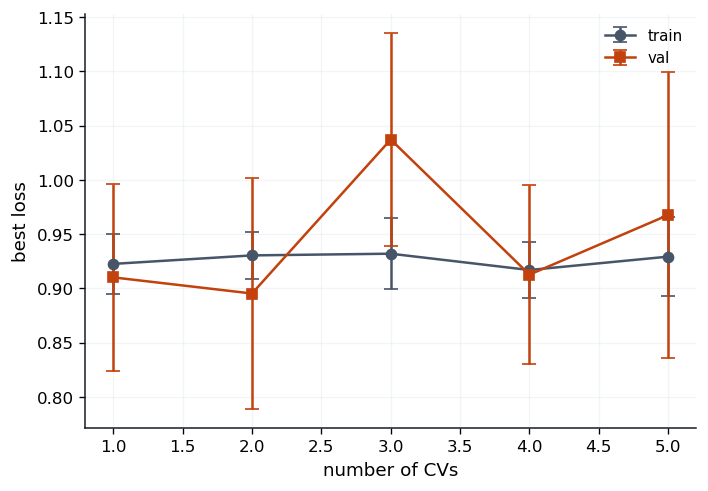

Partial sweep: best checkpoint cv_fit_r2 versus number of CVs


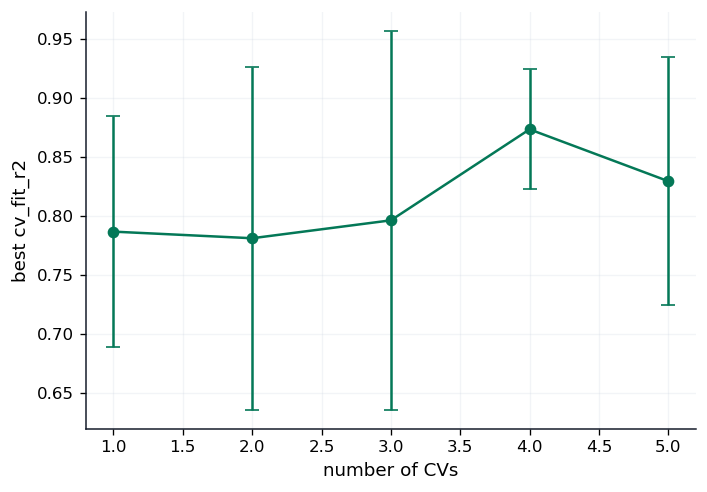

Partial sweep: downstream single-CV test performance versus number of CVs


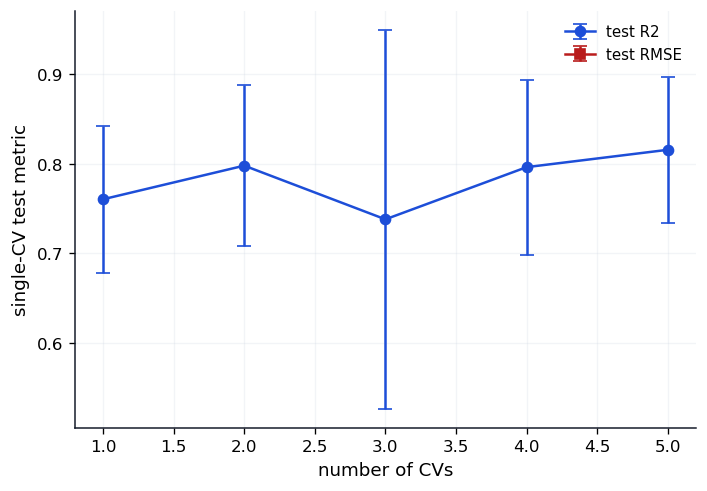

Partial sweep: downstream linear-combo test performance versus number of CVs


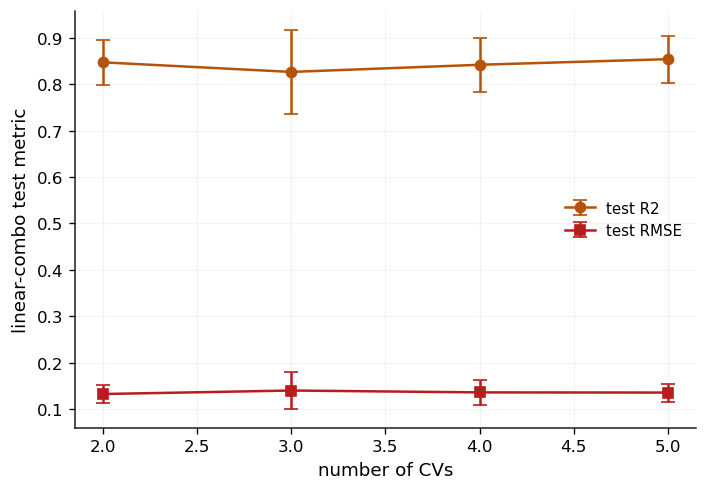

saved: ../results/cv_transformer_cvcount_sweep/cv_count_sweep_partial_runs.csv
saved: ../results/cv_transformer_cvcount_sweep/cv_count_sweep_partial_summary.csv


In [ ]:
sweep_read_root = Path('../results/cv_transformer_cvcount_sweep')
read_rows = []
for trial_dir in sorted([pp for pp in sweep_read_root.iterdir() if pp.is_dir()]):
    name = trial_dir.name
    if not name.startswith('cvcount_'):
        continue
    parts = name.split('_')
    if len(parts) < 4:
        continue
    cv_count = int(parts[1])
    run_idx = int(parts[3])
    stats_path = trial_dir / 'train_stats.pt'
    eval_path = trial_dir / 'cv_pratio_eval_summary.json'
    if not stats_path.exists():
        continue
    stats = torch.load(stats_path, map_location='cpu', weights_only=False)
    epochs = np.asarray(stats.get('epoch', []), dtype=float)
    train_loss = np.asarray([np.nan if v is None else float(v) for v in stats.get('loss', [])], dtype=float)
    val_loss = np.asarray([np.nan if v is None else float(v) for v in stats.get('val_loss', [])], dtype=float)
    cv_fit_r2 = np.asarray([np.nan if v is None else float(v) for v in stats.get('cv_fit_r2', [])], dtype=float)
    row = {
        'CVs': cv_count,
        'run_idx': run_idx,
        'has_train_stats': True,
        'has_eval_summary': eval_path.exists(),
        'best_train_loss': float(np.nanmin(train_loss)) if np.isfinite(train_loss).any() else np.nan,
        'best_val_loss': float(np.nanmin(val_loss)) if np.isfinite(val_loss).any() else np.nan,
        'best_cv_fit_r2': float(np.nanmax(cv_fit_r2)) if np.isfinite(cv_fit_r2).any() else np.nan,
        'best_train_loss_epoch': int(epochs[np.nanargmin(train_loss)]) if np.isfinite(train_loss).any() else np.nan,
        'best_val_loss_epoch': int(epochs[np.nanargmin(val_loss)]) if np.isfinite(val_loss).any() else np.nan,
        'best_cv_fit_r2_epoch': int(epochs[np.nanargmax(cv_fit_r2)]) if np.isfinite(cv_fit_r2).any() else np.nan,
    }
    if eval_path.exists():
        eval_summary = json.loads(eval_path.read_text())
        row.update({
            'selected_cv': eval_summary.get('selected_cv'),
            'selected_cv_test_fit_r2': eval_summary.get('selected_cv_test_fit_r2', np.nan),
            'selected_cv_test_rmse': eval_summary.get('selected_cv_test_rmse', np.nan),
            'linear_combo_features': ', '.join(eval_summary.get('linear_combo_features', [])) if isinstance(eval_summary.get('linear_combo_features'), list) else eval_summary.get('linear_combo_features'),
            'linear_combo_test_fit_r2': eval_summary.get('linear_combo_test_fit_r2', np.nan),
            'linear_combo_test_rmse': eval_summary.get('linear_combo_test_rmse', np.nan),
        })
    read_rows.append(row)

existing_sweep_df = pd.DataFrame(read_rows).sort_values(['CVs', 'run_idx']).reset_index(drop=True)
if existing_sweep_df.empty:
    print(f'No partial sweep results found in {sweep_read_root}.')
else:
    status_df = existing_sweep_df.groupby('CVs', as_index=False).agg(
        runs_found=('run_idx', 'count'),
        eval_runs_found=('has_eval_summary', 'sum'),
        mean_best_train_loss=('best_train_loss', 'mean'),
        std_best_train_loss=('best_train_loss', 'std'),
        mean_best_val_loss=('best_val_loss', 'mean'),
        std_best_val_loss=('best_val_loss', 'std'),
        mean_best_cv_fit_r2=('best_cv_fit_r2', 'mean'),
        std_best_cv_fit_r2=('best_cv_fit_r2', 'std'),
        mean_selected_cv_test_fit_r2=('selected_cv_test_fit_r2', 'mean'),
        std_selected_cv_test_fit_r2=('selected_cv_test_fit_r2', 'std'),
        mean_selected_cv_test_rmse=('selected_cv_test_rmse', 'mean'),
        std_selected_cv_test_rmse=('selected_cv_test_rmse', 'std'),
        mean_linear_combo_test_fit_r2=('linear_combo_test_fit_r2', 'mean'),
        std_linear_combo_test_fit_r2=('linear_combo_test_fit_r2', 'std'),
        mean_linear_combo_test_rmse=('linear_combo_test_rmse', 'mean'),
        std_linear_combo_test_rmse=('linear_combo_test_rmse', 'std'),
    )

    paper_caption('Partial CV-count sweep runs currently available on disk')
    display(existing_sweep_df.round(4))
    paper_caption('Partial CV-count sweep summary using only completed runs already on disk')
    display(status_df.round(4))

    paper_caption('Partial sweep: best train and validation loss versus number of CVs')
    fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.2))
    ax.errorbar(status_df['CVs'], status_df['mean_best_train_loss'], yerr=status_df['std_best_train_loss'].fillna(0.0), fmt='o-', capsize=4, label='train', color=PAPER_COLORS['slate'])
    ax.errorbar(status_df['CVs'], status_df['mean_best_val_loss'], yerr=status_df['std_best_val_loss'].fillna(0.0), fmt='s-', capsize=4, label='val', color=PAPER_COLORS['orange'])
    style_axes(ax, xlabel='number of CVs', ylabel='best loss', legend=True)
    plt.tight_layout()
    plt.show()

    paper_caption('Partial sweep: best checkpoint cv_fit_r2 versus number of CVs')
    fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.2))
    ax.errorbar(status_df['CVs'], status_df['mean_best_cv_fit_r2'], yerr=status_df['std_best_cv_fit_r2'].fillna(0.0), fmt='o-', capsize=4, color=PAPER_COLORS['green'])
    style_axes(ax, xlabel='number of CVs', ylabel='best cv_fit_r2')
    plt.tight_layout()
    plt.show()

    paper_caption('Partial sweep: downstream single-CV test performance versus number of CVs')
    fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.2))
    ax.errorbar(status_df['CVs'], status_df['mean_selected_cv_test_fit_r2'], yerr=status_df['std_selected_cv_test_fit_r2'].fillna(0.0), fmt='o-', capsize=4, label='test R2', color=PAPER_COLORS['blue'])
    ax.errorbar(status_df['CVs'], status_df['mean_selected_cv_test_rmse'], yerr=status_df['std_selected_cv_test_rmse'].fillna(0.0), fmt='s-', capsize=4, label='test RMSE', color=PAPER_COLORS['red'])
    style_axes(ax, xlabel='number of CVs', ylabel='single-CV test metric', legend=True)
    plt.tight_layout()
    plt.show()

    if status_df['eval_runs_found'].fillna(0).sum() > 0:
        paper_caption('Partial sweep: downstream linear-combo test performance versus number of CVs')
        fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.2))
        ax.errorbar(status_df['CVs'], status_df['mean_linear_combo_test_fit_r2'], yerr=status_df['std_linear_combo_test_fit_r2'].fillna(0.0), fmt='o-', capsize=4, label='test R2', color=PAPER_COLORS['gold'])
        ax.errorbar(status_df['CVs'], status_df['mean_linear_combo_test_rmse'], yerr=status_df['std_linear_combo_test_rmse'].fillna(0.0), fmt='s-', capsize=4, label='test RMSE', color=PAPER_COLORS['red'])
        style_axes(ax, xlabel='number of CVs', ylabel='linear-combo test metric', legend=True)
        plt.tight_layout()
        plt.show()

    partial_runs_csv = sweep_read_root / 'cv_count_sweep_partial_runs.csv'
    partial_summary_csv = sweep_read_root / 'cv_count_sweep_partial_summary.csv'
    existing_sweep_df.to_csv(partial_runs_csv, index=False)
    status_df.to_csv(partial_summary_csv, index=False)
    print('saved:', partial_runs_csv)
    print('saved:', partial_summary_csv)
